---
title: "[Law Graph Visualization](https://colab.research.google.com/drive/1bS6ZMkCtmqrbWvSQLC-Y6crRXwrKyYKI?usp=sharing)"
---




This notebook presents an interactive visualization of the **legal knowledge graph**.  
The graph makes explicit the structural relationships between statutory provisions that are otherwise difficult to observe through text-only retrieval.

This visualization serves both as a **diagnostic tool** and as an **explanatory aid** for understanding how graph enhancement influences retrieval and downstream answer generation.

In [1]:
#| include: false

import os
from pathlib import Path
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_TF"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

ROOT = Path("/content").resolve()
os.chdir(ROOT)
print("ROOT:", ROOT)

REPO_URL = "https://github.com/Fan-Luo/Legal-RAG.git"
REPO_DIR = ROOT / "Legal-RAG"
os.environ["REPO_DIR"] = str(REPO_DIR)

if not REPO_DIR.exists():
    !git clone "$REPO_URL" "$REPO_DIR"
else:
    %cd "$REPO_DIR"
    !git pull


%cd "$REPO_DIR"
!pip install -e .
print("Current dir:", Path.cwd())

ROOT: /content
Cloning into '/content/Legal-RAG'...
remote: Enumerating objects: 656, done.
remote: Counting objects: 100% (205/205), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 656 (delta 153), reused 147 (delta 136), pack-reused 451 (from 1)
Receiving objects: 100% (656/656), 402.82 KiB | 4.91 MiB/s, done.
Resolving deltas: 100% (345/345), done.
/content/Legal-RAG
Obtaining file:///content/Legal-RAG
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... d

In [2]:
#| include: false

import json, os
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, deque
from legalrag.schemas import LawNode, Neighbor
from typing import Any, Dict, Iterable, List, Optional, Tuple
from pathlib import Path
import pandas as pd
import matplotlib as mpl
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

mpl.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "SimHei", "Arial Unicode MS"]
mpl.rcParams["axes.unicode_minus"] = False
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
#| include: false

import logging

def setup_logging(
    level=logging.INFO,
    fmt="%(message)s",
    scope="legalrag",
):
    """
    Configure logging for the LegalRAG repository.

    This function removes existing handlers attached to loggers
    under the given scope and installs a clean StreamHandler.
    """
    base = logging.getLogger(scope)
    base.setLevel(level)

    # Remove all handlers under this scope
    for name, logger in logging.root.manager.loggerDict.items():
        if name == scope or name.startswith(scope + "."):
            lg = logging.getLogger(name)
            for h in lg.handlers[:]:
                lg.removeHandler(h)
            lg.propagate = False

    # Attach a single handler to base logger
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter(fmt))
    base.addHandler(handler)

setup_logging(fmt="%(message)s")

## Build and Load the Graph

After pull the project source code, the preprocessing stage constructs a legal knowledge graph to capture structural relationships:
```python
git clone https://github.com/Fan-Luo/Legal-RAG.git
pip install -e .
python -m scripts.preprocess_law
python -m scripts.build_graph
```

In [4]:
#| include: false

# For demo purpose, load preprocessed law data
!python -m data.download_data

[download_data] data dir=/content/Legal-RAG/data
[download_data] repo_id=flora-l/lawdata repo_type=dataset zip=data.zip
data.zip: 100% 8.78M/8.78M [00:00<00:00, 10.5MB/s]
[download_data] downloaded_zip=/root/.cache/huggingface/hub/datasets--flora-l--lawdata/blobs/151e7efe768ae925b93f761f81a33fcd504a960089af9ff5ef6d91563d64b836
[download_data] wrote: /content/Legal-RAG/data/download_data.py
[download_data] wrote: /content/Legal-RAG/data/raw/minfadian.txt
[download_data] wrote: /content/Legal-RAG/data/graph/law_graph.jsonl
[download_data] wrote: /content/Legal-RAG/data/index/bm25.pkl
[download_data] wrote: /content/Legal-RAG/data/index/faiss/faiss_meta.jsonl
[download_data] wrote: /content/Legal-RAG/data/index/faiss/faiss.index
[download_data] wrote: /content/Legal-RAG/data/index/colbert/.colbert_build.lock
[download_data] wrote: /content/Legal-RAG/data/index/colbert/colbert_meta.jsonl
[download_data] wrote: /content/Legal-RAG/data/index/colbert/experiment/indexes/law/centroids.pt
[downl

## What This Graph Represents

- **Nodes** correspond to individual legal provisions (e.g., articles or clauses).
- **Edges** encode structural relationships, capturing  referential and contextual dependencies among laws.

The graph is constructed offline from preprocessed legal texts and stored as a static HTML artifact for reproducible inspection.

In [5]:
#| code-fold: false

from legalrag.config import AppConfig
from legalrag.retrieval.graph_store import LawGraphStore

cfg = AppConfig.load(None)
store = LawGraphStore(cfg)
store.load()

2026-01-20 20:08:22,118 - legalrag.retrieval.graph_store - INFO - [Graph] Loaded 1260 law nodes
2026-01-20 20:08:22,123 - legalrag.retrieval.graph_store - INFO - [Graph] Built adjacency: 2640 edges


In [6]:
#| echo: false
#| code-fold: false

node = store.nodes["142"]

print("Example graph node:")
print(f"  Article ID   : {node.article_id}")
print(f"  Article No   : {node.article_no}")
print(f"  Law          : {node.law_name}")
print(f"  Chapter      : {node.chapter}")
print(f"  Section      : {node.section}")
print()
print("  Neighbors:")
for nb in node.neighbors:
    print(
        f"    - {nb.article_id:>4} | "
        f"rel={nb.relation:<6} | "
        f"conf={nb.conf:.2f} | "
        f"evidence={nb.evidence}"
    )


Example graph node:
  Article ID   : 142
  Article No   : 第一百四十二条
  Law          : 中华人民共和国民法典
  Chapter      : 六章 民事法律行为
  Section      : 三节 民事法律行为的效力

  Neighbors:
    -  141 | rel=prev   | conf=1.00 | evidence=None
    -  143 | rel=next   | conf=1.00 | evidence=None
    -  466 | rel=cited  | conf=0.90 | evidence={'span': [30, 37], 'text': '第一百四十二条'}


In [7]:
#| include: false

neighbors = store.nodes['142'].neighbors
neighbors

[Neighbor(article_id='141', relation='prev', conf=1.0, evidence=None),
 Neighbor(article_id='143', relation='next', conf=1.0, evidence=None),
 Neighbor(article_id='466', relation='cited', conf=0.9, evidence={'span': [30, 37], 'text': '第一百四十二条'})]

## Graph Walk Retrieval

Graph-based expansion performs a bounded breadth-first search (BFS) over the legal knowledge graph, starting from one or more seed articles. The goal is to retrieve a localized subgraph centered on the query nodes, while allowing fine-grained control over relation types, confidence thresholds, and the total number of returned nodes. The resulting nodes are used to induce a subgraph for visualization or downstream analysis.

In [9]:
#| echo: false
#| code-fold: false

G = nx.DiGraph()

# Add nodes
for node in store.adj.keys():
    G.add_node(node)

# Add edges with relation labels
for src, node in store.nodes.items():
    for e in node.neighbors:
        G.add_edge(src, e.article_id, relation=e.relation)

In [8]:
#| code-summary: Perform a graph walk from seed legal articles to retrieve a localized subgraph
#| code-fold: false

start_ids = ["582"]
law_nodes = store.walk(start_ids, limit = 30)
node_ids = [node.article_id for node in law_nodes] + start_ids

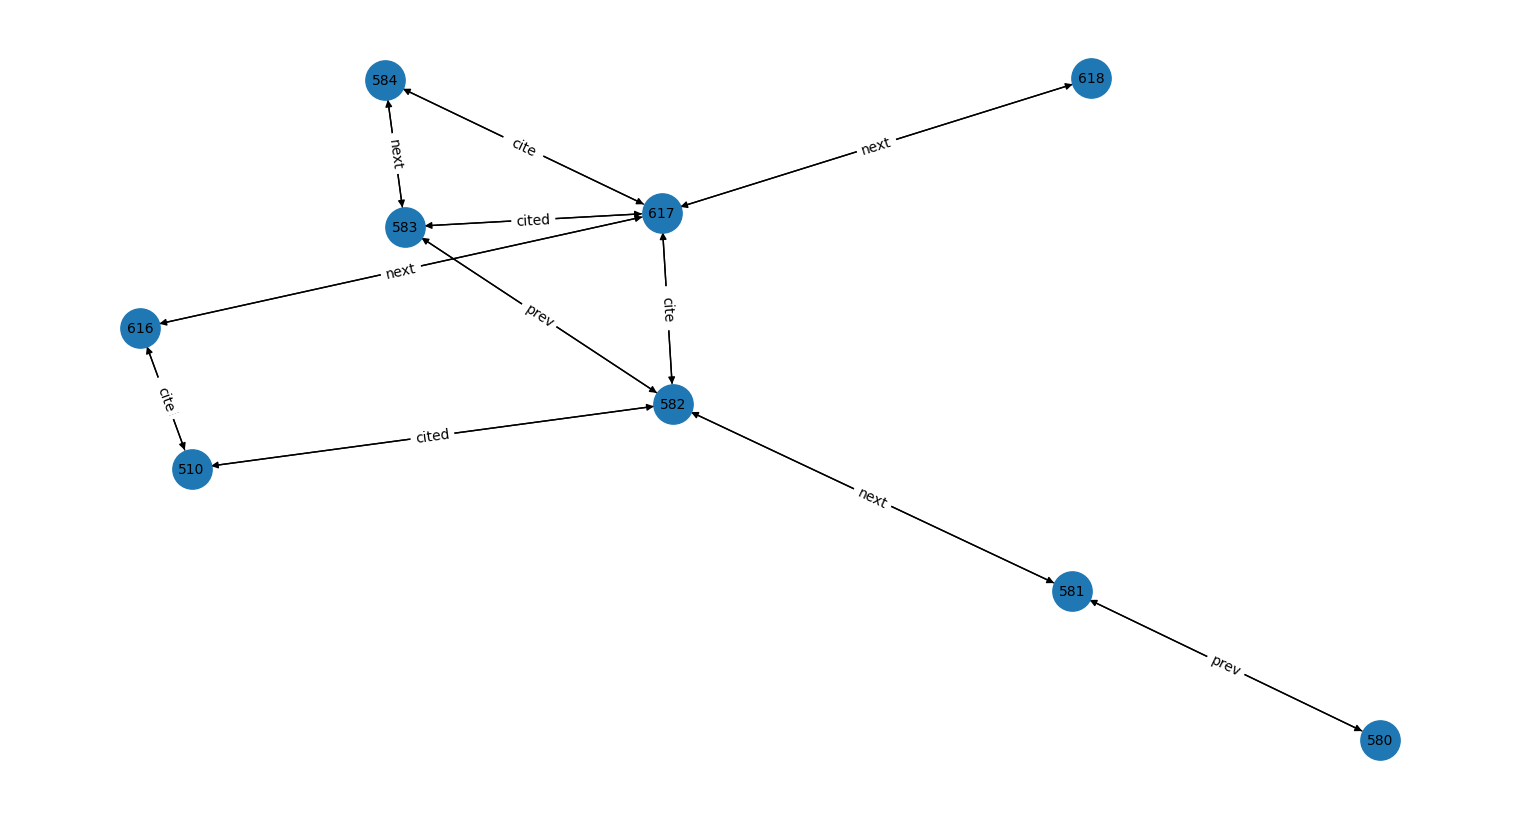

In [10]:
#| echo: false

sub = G.subgraph(node_ids)
plt.figure(figsize=(15, 8))
pos = nx.spring_layout(sub, seed=42)
nx.draw(sub, pos, with_labels=True, node_size=800, font_size=10)
nx.draw_networkx_edge_labels(sub, pos, edge_labels=nx.get_edge_attributes(sub, "relation"))
plt.show()

## Visualizing the Legal Knowledge Graph

This section visualizes the full legal knowledge graph as an interactive network to facilitate inspection and analysis of structural relationships between legal articles. Nodes represent individual law articles, while directed edges encode relational links such as sequential ordering, citations, or doctrinal dependencies.

This visualization complements quantitative retrieval metrics by providing a **qualitative view** of legal structure and coverage.


In [11]:
#| echo: false
#| code-fold: false

from pyvis.network import Network
import os

# Create network (notebook=True for inline display in Jupyter/Quarto)
net = Network(
    notebook=True,
    height="900px",
    width="100%",
    bgcolor="#ffffff",
    font_color="black",
    cdn_resources="in_line"
)

# Add nodes with Chinese-friendly styling
for n in G.nodes():
    net.add_node(
        n,
        label=str(n),
        title=f"Article {n}",
        shape="circle",
        size=25,
        color={
            "background": "#97c2fc",
            "border": "#2b7ce9"
        },
        font={
            "color": "#000000",
            "size": 14,
            "face": "Microsoft YaHei, Helvetica, Arial, sans-serif",
            "align": "middle",
            "multi": True,
            "bold": True
        }
    )

# Add edges
for u, v, data in G.edges(data=True):
    net.add_edge(
        u, v,
        label=data.get("relation", ""),
        font={"size": 11, "align": "middle"}
    )

# Save to file (optional, for external use)
GRAPH_PATH = "data/graph/law_graph.html"
net.write_html(GRAPH_PATH)



<iframe
  src="../data/graph/law_graph.html"
  width="100%"
  height="900"
  style="border: none;"
  loading="lazy">
</iframe>


In [12]:
#| include: false

# from IPython.display import HTML, display

# with open(GRAPH_PATH, "r", encoding="utf-8") as f:
#     display(HTML(f.read()))